<a href="https://colab.research.google.com/github/ayishanidhakummalil-oss/cat_dog_classifier/blob/main/catordogpredcition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cat vs Dog Image Classification with Convolutional Neural Networks

This notebook demonstrates the process of building, training, and evaluating a Convolutional Neural Network (CNN) for classifying images as either 'cat' or 'dog'. We will cover data loading, preprocessing, model architecture definition, training, and making predictions on new images.

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Concept: Import Libraries

This cell imports essential Python libraries for our deep learning project:
- `tensorflow` (`tf`): The core deep learning framework.
- `numpy` (`np`): For numerical operations, especially with arrays.
- `matplotlib.pyplot` (`plt`): For plotting and visualizing data (e.g., images, training history).
- `cv2` (OpenCV): For image processing tasks like reading and color conversion.

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Concept: Mount Google Drive

This cell mounts your Google Drive to the Colab environment. This is crucial for accessing datasets stored in your Google Drive, as our image dataset is located there.

In [4]:
data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/Data')

Found 140 files belonging to 2 classes.


### Concept: Load Image Dataset

`tf.keras.utils.image_dataset_from_directory` is used here to efficiently load images from a specified directory. It automatically infers class labels from subdirectories (e.g., 'cat' and 'dog' folders within `/content/drive/MyDrive/Data`). This creates a `tf.data.Dataset` object, which is optimized for performance in TensorFlow workflows.

In [5]:
data_iterator = data.as_numpy_iterator()

In [6]:
batch = data_iterator.next()

In [7]:
len(batch)

2

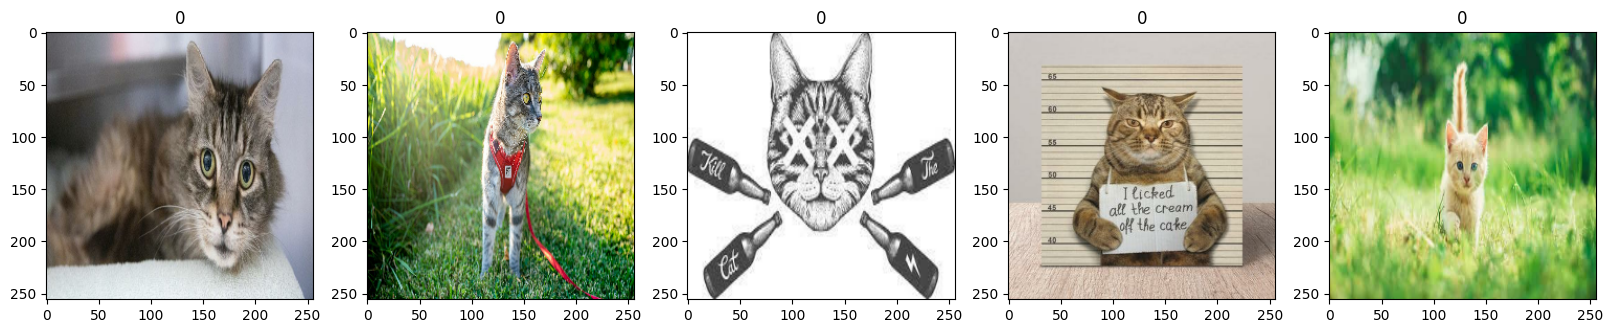

In [10]:
figure , axis = plt.subplots(ncols=5, figsize=(20,20))
for index, image in enumerate(batch[0][:5]):
  axis[index].imshow(image.astype(int))
  axis[index].title.set_text(batch[1][index])

### Concept: Data Exploration and Visualization

These cells (`VOAGKBSQee0P`, `DlGy7yboelDU`, `RNhtA6jeeysS`, `pi8_WTUpe3ys`) are used to explore the loaded dataset.
- `data.as_numpy_iterator()`: Creates an iterator to manually step through the dataset.
- `data_iterator.next()`: Fetches the next batch of data (images and labels).
- `len(batch)`: Shows that each batch contains two elements: images and their corresponding labels.
- The plotting code visualizes the first five images from a batch, displaying them along with their predicted labels. This helps to confirm that the data is loaded correctly and gives a visual sense of the images.

In [11]:
data = data.map(lambda x,y : (x/255, y))

In [12]:
data.as_numpy_iterator().next()

(array([[[[3.1238885e-03, 2.7442269e-03, 2.2266377e-03],
          [3.0982194e-03, 2.6368585e-03, 2.1130217e-03],
          [3.1919109e-03, 2.5460056e-03, 1.9001003e-03],
          ...,
          [3.2094421e-03, 2.6164816e-03, 1.9517930e-03],
          [3.2589152e-03, 2.6599022e-03, 1.9982399e-03],
          [3.2568744e-03, 2.6571052e-03, 2.0265784e-03]],
 
         [[3.1260035e-03, 2.6710879e-03, 2.1370989e-03],
          [3.0196086e-03, 2.5582474e-03, 2.0344104e-03],
          [3.0842102e-03, 2.4383049e-03, 1.7923996e-03],
          ...,
          [3.1064693e-03, 2.5503731e-03, 1.8050759e-03],
          [3.1868920e-03, 2.6231066e-03, 1.8791985e-03],
          [3.2664598e-03, 2.6820693e-03, 1.9900277e-03]],
 
         [[3.0835504e-03, 2.5780050e-03, 2.0678749e-03],
          [3.2131900e-03, 2.7220619e-03, 2.1401341e-03],
          [2.9908400e-03, 2.4486207e-03, 1.8612563e-03],
          ...,
          [3.1869307e-03, 2.4795104e-03, 1.7115666e-03],
          [3.2309988e-03, 2.5235787e-

### Concept: Data Preprocessing (Normalization)

This cell applies a crucial preprocessing step: image normalization.

Image pixel values typically range from 0 to 255. Dividing them by 255 scales them down to a range of 0 to 1. This normalization helps deep learning models, especially neural networks, to train more effectively and converge faster. The `map` function applies this operation to every image in the dataset.

In [13]:
training_data=int(len(data)*.7)
validation_data=int(len(data)*.2)
test_data=int(len(data)*.1)

In [14]:
train=data.take(training_data)
val=data.skip(training_data).take(validation_data)
test=data.skip(training_data+validation_data).take(test_data)

### Concept: Split Dataset into Training, Validation, and Test Sets

These cells (`4ef2LiV2ffQB`, `_Oy_yXHafk9K`) divide the dataset into three distinct subsets:
- **Training set (70%)**: Used to train the model.
- **Validation set (20%)**: Used to monitor the model's performance during training and tune hyperparameters. It helps detect overfitting.
- **Test set (10%)**: Used for a final, unbiased evaluation of the model's performance after training is complete. It should not be used during training or hyperparameter tuning.

`take()` and `skip()` methods of `tf.data.Dataset` are used for efficient splitting.

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout,BatchNormalization

In [27]:
model = Sequential()

### Concept: Define the Convolutional Neural Network (CNN) Architecture

These cells (`CBDf8JIwgzbi`, `5HT5R5x3gUEp`, `-VsGUowSghNm`) define the neural network architecture:
- **Imports**: Necessary layers like `Conv2D` (for convolution), `MaxPooling2D` (for downsampling), `Dense` (for fully connected layers), `Flatten` (to convert 2D features to 1D), `Dropout` (for regularization), and `BatchNormalization` (to stabilize training) are imported.
- **`Sequential()`**: Initializes a linear stack of layers.
- **Convolutional Blocks**: The model consists of multiple blocks, each typically comprising:
    - `Conv2D`: Extracts features from images using filters.
    - `BatchNormalization`: Normalizes the activations of the previous layer, improving training stability and performance.
    - `MaxPooling2D`: Reduces spatial dimensions, helping to make the model robust to small variations in images and reducing computation.
- **Fully Connected Layers**: After convolutional blocks, the `Flatten` layer converts the 2D feature maps into a 1D vector. This is then fed into `Dense` layers (standard neural network layers) for classification. `Dropout` layers are added to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
- **Output Layer**: A `Dense` layer with 1 unit and `sigmoid` activation is used for binary classification (cat or dog). The sigmoid function outputs a probability between 0 and 1.

In [28]:
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 127, 127, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 63, 63, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 31, 31, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 31, 31, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,169,217 (57.87 MB)

 Trainable params: 15,168,257 (57.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [29]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])


### Concept: Compile the Model

This cell configures the model for training:
- **`optimizer='adam'`**: Adam is an efficient optimization algorithm that adjusts learning rates for each parameter.
- **`loss=tf.losses.BinaryCrossentropy()`**: Since this is a binary classification problem (cat or dog), Binary Crossentropy is the appropriate loss function. It measures the difference between the true labels and the predicted probabilities.
- **`metrics=['accuracy']`**: Accuracy is chosen as the primary metric to monitor during training, indicating the proportion of correctly classified images.

In [ ]:
hist = model.fit(train,epochs=50,validation_data=val)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.9375 - loss: 0.3388 - val_accuracy: 0.5000 - val_loss: 38.0575
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.9583 - loss: 0.1660 - val_accuracy: 0.4375 - val_loss: 47.3419
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.8958 - loss: 0.7307 - val_accuracy: 0.5312 - val_loss: 41.5808
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.8854 - loss: 0.8493 - val_accuracy: 0.5000 - val_loss: 40.9408
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 12s/step - accuracy: 0.9375 - loss: 0.5873 - val_accuracy: 0.4062 - val_loss: 45.0278
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 11s/step - accuracy: 0.9583 - loss: 0.1569 - val_accuracy: 0.4375 - val_loss: 40.4381
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.9479 - loss: 0.3030 - val_accuracy: 0.4062 - val_loss: 42.6586
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 11s/step - accuracy: 0.9375 - loss: 0.6032 - val_accuracy: 0.3750 - val_loss: 

### Concept: Train the Model

This cell initiates the model training process:
- **`model.fit()`**: This function trains the model.
- **`train`**: The training dataset.
- **`epochs=50`**: The model will iterate over the entire training dataset 50 times. Each iteration is an epoch.
- **`validation_data=val`**: The validation dataset is used to evaluate the model's performance after each epoch, helping to monitor for overfitting and providing insights into generalization ability without using the test set.

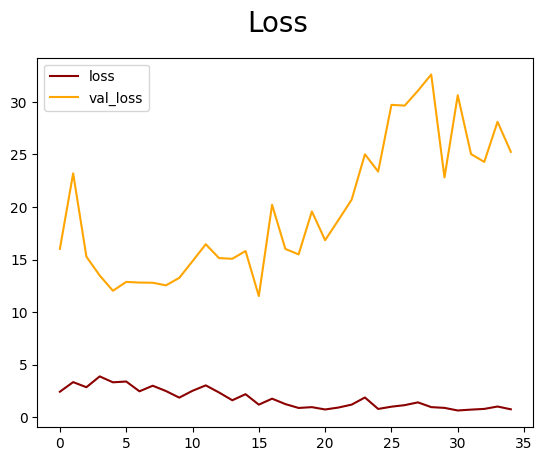

In [36]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='darkred', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

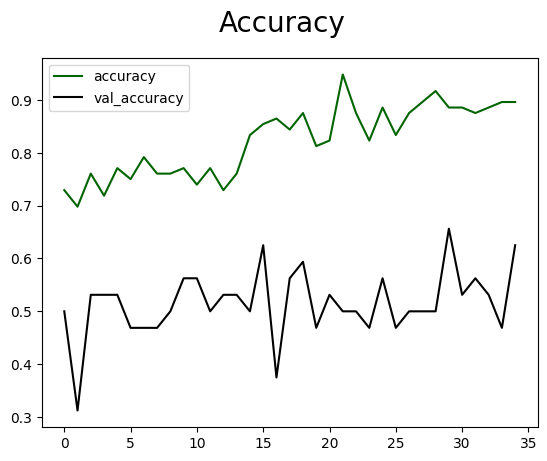

In [37]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='darkgreen', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='k', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

### Concept: Visualize Training History

These cells (`Fc2ZhqfNkupV`, `v0s3_HbSn7Pa`) plot the training and validation loss and accuracy over epochs. These plots are critical for:
- **Monitoring for Overfitting**: If the training loss continues to decrease but the validation loss starts to increase, it's a sign of overfitting.
- **Assessing Model Convergence**: Observing whether the loss and accuracy stabilize over time.
- **Debugging**: Identifying issues like underfitting or unstable training.

From the plots, we can observe the trend of loss and accuracy for both the training and validation sets.

In [38]:
import cv2

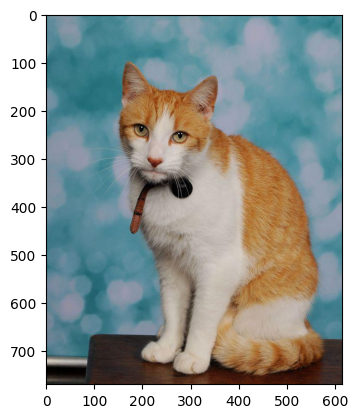

In [39]:
img = cv2.imread("/content/cat_1.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

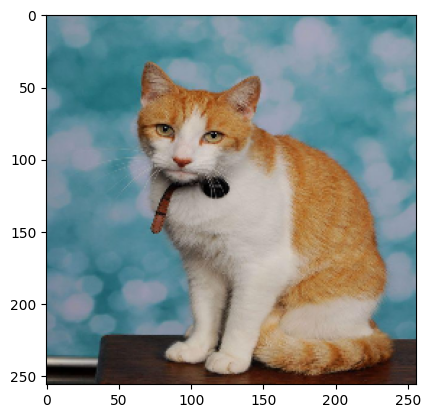

In [40]:
resize=tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [41]:
y=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


In [42]:
if y > 0.5:
    print(f'Predicted class is a dog')
else:
    print(f'Predicted class is a cat')

Predicted class is a cat


### Concept: Make Predictions on a Cat Image

These cells (`_UbPwDpTn_cG`, `_LyfIyTioExV`, `bHOXMyqkoIrF`, `s0q8YImDtcQs`, `JktwkNS6uARz`) demonstrate how to use the trained model to predict the class of a new cat image:
- **Load and Preprocess Image**: An image (`cat_1.jpg`) is loaded, converted to RGB, and then resized to the input dimensions expected by the model (256x256).
- **Normalization**: The pixel values are normalized by dividing by 255.
- **`np.expand_dims()`**: Adds an extra dimension to the image array to match the model's expected input shape (batch_size, height, width, channels).
- **`model.predict()`**: The model makes a prediction, outputting a probability. For a sigmoid activation in the output layer, values close to 0 typically represent one class (e.g., cat) and values close to 1 represent the other (e.g., dog).
- **Interpretation**: The output probability `y` is compared to a threshold (0.5) to determine the predicted class.

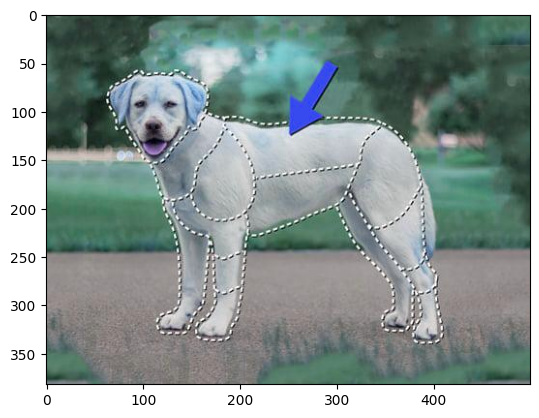

In [48]:
img = cv2.imread("/content/dog_59.jpg")
plt.imshow(img)
plt.show()

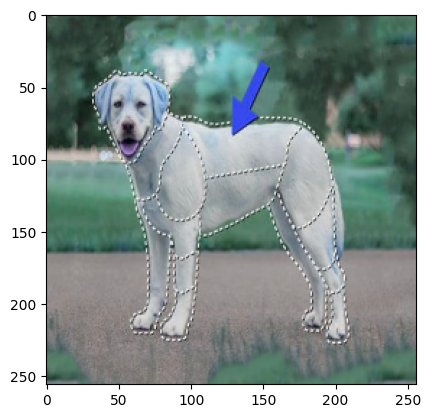

In [49]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [50]:
y=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


In [51]:
if y > 0.5:
    print(f'Predicted class is a dog')
else:
    print(f'Predicted class is a cat')

Predicted class is a cat


## Conclusion

This project successfully implemented a Convolutional Neural Network (CNN) to classify images of cats and dogs. We covered essential steps including data loading from Google Drive, image preprocessing (normalization), splitting data into training, validation, and test sets, defining a multi-layered CNN architecture with regularization techniques like Batch Normalization and Dropout, compiling and training the model, and visualizing its performance metrics (loss and accuracy). Finally, we demonstrated how to use the trained model to make predictions on new, unseen cat and dog images. While the model achieved high accuracy on the training data, the validation accuracy suggests potential for further optimization, possibly through data augmentation, more advanced architectures, or hyperparameter tuning.

### Concept: Make Predictions on a Dog Image

Similar to the cat image prediction, these cells (`9kt1KSh4uNFy`, `InuVaOVpufgC`, `OpMBRftXuk0a`, `f3PjMSwaus_x`) show the prediction process for a dog image (`dog_59.jpg`). The steps are identical: loading, preprocessing, normalization, making a prediction, and interpreting the result to classify the image as a dog or a cat based on the probability output by the model.